# Dublin Bus Reliability Disparity — Full Analysis
Run this notebook top-to-bottom. All figures are saved to `results/`.

## 0. Setup

In [1]:
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)

DB = 'data/dublin_bus.db'
conn = sqlite3.connect(DB)
print('Connected to', DB)

Connected to data/dublin_bus.db


## 1. Data Overview & Window Definitions

All timestamps in the DB are UTC. Ireland is on IST (UTC+1), so displayed times are UTC+1.

In [2]:
# Four collection windows (UTC boundaries â€” DB stores UTC, Ireland is IST = UTC+1)
WINDOWS = {
    'Morning Peak\n(06:00â€“09:00 IST)':    ('2026-04-21T05:00', '2026-04-21T08:00'),
    'Evening Peak\n(16:00â€“19:00 IST)':    ('2026-04-21T15:00', '2026-04-21T18:00'),
    'Wed Midday\n(12:00â€“15:00 IST)':      ('2026-04-22T11:00', '2026-04-22T14:00'),
}

# Short labels for figures
WINDOW_SHORT = {
    'Morning Peak\n(06:00â€“09:00 IST)':    'Mon Morning Peak',
    'Evening Peak\n(16:00â€“19:00 IST)':    'Mon Evening Peak',
    'Wed Midday\n(12:00â€“15:00 IST)':      'Wed Midday',
}

# Dublin Bus operator prefixes across both collection periods
DUBLIN_BUS_PREFIXES = ('5549_')

def window_filter(label):
    start, end = WINDOWS[label]
    prefix_clause = " OR ".join(f"route_id LIKE '{p}%'" for p in DUBLIN_BUS_PREFIXES)
    return f"collected_at >= '{start}' AND collected_at < '{end}' AND ({prefix_clause})"

for label, (start, end) in WINDOWS.items():
    filt = window_filter(label)
    n = conn.execute(f"""
        SELECT COUNT(*) FROM delay_observations
        WHERE is_valid=1 AND {filt}
    """).fetchone()[0]
    n_routes = conn.execute(f"""
        SELECT COUNT(DISTINCT route_id) FROM delay_observations
        WHERE is_valid=1 AND {filt}
    """).fetchone()[0]
    print(f'{WINDOW_SHORT[label]:20s}: {n:>10,} obs  |  {n_routes} routes')

Mon Morning Peak    :    553,644 obs  |  173 routes
Mon Evening Peak    :    926,851 obs  |  170 routes
Wed Midday          :    816,485 obs  |  156 routes


## 2. Route Name & Region Assignment

For `5549_` routes (April 21 collection) we use the same route number geography since Dublin Bus route numbers are stable.

In [39]:
# Load 5549_ route ID to short name mapping
route_map = pd.read_csv('data/route_id_map.csv', dtype=str)
route_map['route_short_name'] = route_map['route_short_name'].str.strip().str.upper()

# Dublin Bus region mapping by route short name
NORTH = {
    '1','2','3','11','13X','16','16C','17','17A','27','27X','29A',
    '31','31A','31B','32','32X','33','33X','41','41B','41C','41D','41X',
    '42','42D','43','44','44B','53','83','83A',
    '101','102','104','109','116','120','122','123','130','142','145',
}
SOUTH = {
    '7','7A','7B','7D','8','14','14C','15','15A','15B',
    '44','61','63','65','65B','68','68A','75','77A','77X',
    '84','84A','84X','116',
}
WEST = {
    '13','25','25A','25B','25D','25X','26','37','38','38A',
    '39','39A','39X','40','40B','40D','51','51B','51D','51X',
    '66','66A','66B','66X','67','67X','69','69X','70','70X',
    '76','76A','79','79A',
}
CITY_CENTRE = {
    '4','9','10','46A','47','49','54A','56A','65','66','67',
    '68','68X','69','145','747','757',
}

def assign_region(short_name):
    s = str(short_name).upper().strip()
    if s in CITY_CENTRE: return 'City Centre'
    if s in NORTH:       return 'North Dublin'
    if s in SOUTH:       return 'South Dublin'
    if s in WEST:        return 'West Dublin'
    try:
        n = int(''.join(c for c in s if c.isdigit()))
        if n <= 19:   return 'City Centre'
        if n <= 39:   return 'North Dublin'
        if n <= 69:   return 'West Dublin'
        if n <= 84:   return 'South Dublin'
        return 'North Dublin'
    except:
        return 'Unknown'

route_map['region'] = route_map['route_short_name'].apply(assign_region)

print(route_map['region'].value_counts())
print(f'\nRoutes with region assigned: {(route_map["region"] != "Unknown").sum()} / {len(route_map)}')

region
Unknown         79
North Dublin    38
City Centre     34
South Dublin    15
West Dublin     14
Name: count, dtype: int64

Routes with region assigned: 101 / 180


In [42]:
unknown_route_ids = route_map[route_map['route_short_name'].isna()]['route_id'].tolist()

result = conn.execute(f"""
    SELECT COUNT(*) as n_obs,
           COUNT(DISTINCT route_id) as n_routes
    FROM delay_observations
    WHERE route_id IN ({','.join(['?' for _ in unknown_route_ids])})
      AND is_valid = 1
      AND collected_at >= '2026-04-21'
""", unknown_route_ids).fetchone()

total = conn.execute("""
    SELECT COUNT(*) FROM delay_observations
    WHERE is_valid = 1
      AND collected_at >= '2026-04-21'
      AND route_id LIKE '5549_%'
""").fetchone()[0]

print(f'Unknown routes: {result[1]} routes, {result[0]:,} observations')
print(f'Total observations: {total:,}')
print(f'Unknown as % of total: {result[0]/total*100:.1f}%')

Unknown routes: 79 routes, 1,075,411 observations
Total observations: 2,824,392
Unknown as % of total: 38.1%


## 3. Reliability Metrics — Per Route Per Window

In [4]:
def compute_route_metrics(label):
    filt = window_filter(label)
    df = pd.read_sql(f"""
        SELECT
            route_id,
            delay_seconds,
            is_cancelled,
            is_outlier
        FROM delay_observations
        WHERE is_valid = 1 AND {filt}
    """, conn)

    # Separate clean delays (non-outlier, non-cancelled)
    clean = df[(df['is_outlier'] == 0) & (df['is_cancelled'] == 0) & df['delay_seconds'].notna()]

    metrics = clean.groupby('route_id')['delay_seconds'].agg(
        mean_delay='mean',
        median_delay='median',
        std_delay='std',
        p85_delay=lambda x: np.percentile(x, 85),
        p95_delay=lambda x: np.percentile(x, 95),
        n_clean='count',
    ).reset_index()

    # On-time rate: |delay| <= 60s
    on_time = clean.copy()
    on_time['on_time'] = on_time['delay_seconds'].abs() <= 60
    on_time_rate = on_time.groupby('route_id')['on_time'].mean().reset_index()
    on_time_rate.columns = ['route_id', 'on_time_rate']

    # Excess wait time: mean positive delay in minutes
    late = clean[clean['delay_seconds'] > 0]
    ewt = late.groupby('route_id')['delay_seconds'].mean().reset_index()
    ewt.columns = ['route_id', 'excess_wait_time']
    ewt['excess_wait_time'] /= 60

    # Cancellation rate
    total = df.groupby('route_id').size().reset_index(name='n_total')
    cancelled = df[df['is_cancelled'] == 1].groupby('route_id').size().reset_index(name='n_cancelled')
    cancel_df = total.merge(cancelled, on='route_id', how='left').fillna(0)
    cancel_df['cancellation_rate'] = cancel_df['n_cancelled'] / cancel_df['n_total']

    # Merge all
    result = metrics.merge(on_time_rate, on='route_id', how='left')
    result = result.merge(ewt, on='route_id', how='left')
    result = result.merge(cancel_df[['route_id', 'cancellation_rate']], on='route_id', how='left')
    result['window'] = WINDOW_SHORT[label]
    return result

window_metrics = {}
for label in WINDOWS:
    wm = compute_route_metrics(label)
    window_metrics[WINDOW_SHORT[label]] = wm
    print(f'{WINDOW_SHORT[label]:20s}: {len(wm)} routes, mean delay = {wm["mean_delay"].mean():.1f}s')

Mon Morning Peak    : 172 routes, mean delay = 207.9s
Mon Evening Peak    : 170 routes, mean delay = 414.2s
Wed Midday          : 152 routes, mean delay = 290.3s


In [38]:
route_map = pd.read_csv('data/route_id_map.csv', dtype=str)
print(route_map.shape)
print(route_map.head(10))
print(route_map.columns.tolist())

(180, 3)
      route_id route_short_name  \
0  5549_127721                6   
1  5549_127722               13   
2  5549_127723               14   
3  5549_127724               15   
4  5549_127725               16   
5  5549_127726               19   
6  5549_127729               27   
7  5549_127730               33   
8  5549_127731               37   
9  5549_127732               38   

                                   route_long_name  
0              Howth Dart Stn - Lower Abbey Street  
1                       Grange Castle - Harristown  
2          Dundrum Luas Stn - Ardlea Rd (Beaumont)  
3                   Ballycullen Road - Clongriffin  
4                      Ballinteer - Dublin Airport  
5             Parnell Square West - Dublin Airport  
6                            Jobstown - Clare Hall  
7                      Balbriggan - Lower Abbey St  
8  Blanchardstown Shopping Centre - Wilton Terrace  
9                      Damastown - Burlington Road  
['route_id', 'route_sh

In [5]:
# Combined (all windows) — used for main clustering
all_obs = pd.read_sql("""
    SELECT route_id, delay_seconds, is_cancelled, is_outlier
    FROM delay_observations
    WHERE is_valid = 1
      AND (route_id LIKE '5549_%')
""", conn)

clean_all = all_obs[(all_obs['is_outlier'] == 0) & (all_obs['is_cancelled'] == 0) & all_obs['delay_seconds'].notna()]

route_metrics_all = clean_all.groupby('route_id')['delay_seconds'].agg(
    mean_delay='mean',
    median_delay='median',
    std_delay='std',
    p85_delay=lambda x: np.percentile(x, 85),
    p95_delay=lambda x: np.percentile(x, 95),
).reset_index()

ot = clean_all.copy()
ot['on_time'] = ot['delay_seconds'].abs() <= 60
route_metrics_all = route_metrics_all.merge(
    ot.groupby('route_id')['on_time'].mean().reset_index().rename(columns={'on_time': 'on_time_rate'}),
    on='route_id', how='left'
)

late_all = clean_all[clean_all['delay_seconds'] > 0]
ewt_all = late_all.groupby('route_id')['delay_seconds'].mean().reset_index()
ewt_all.columns = ['route_id', 'excess_wait_time']
ewt_all['excess_wait_time'] /= 60
route_metrics_all = route_metrics_all.merge(ewt_all, on='route_id', how='left')

total_all = all_obs.groupby('route_id').size().reset_index(name='n_total')
canc_all = all_obs[all_obs['is_cancelled'] == 1].groupby('route_id').size().reset_index(name='n_cancelled')
cr = total_all.merge(canc_all, on='route_id', how='left').fillna(0)
cr['cancellation_rate'] = cr['n_cancelled'] / cr['n_total']
route_metrics_all = route_metrics_all.merge(cr[['route_id', 'cancellation_rate']], on='route_id', how='left')

# Join region from static GTFS first
route_metrics_all = route_metrics_all.merge(
    routes_static[['route_id', 'route_short_name', 'region']], 
    on='route_id', how='left')
route_metrics_all['region'] = route_metrics_all['region'].fillna('Unknown')

print(f'Total routes with metrics: {len(route_metrics_all)}')
print(route_metrics_all['region'].value_counts())

Total routes with metrics: 180
region
Unknown    180
Name: count, dtype: int64


In [8]:
# Drop Unknown routes from all analysis dataframes
before = len(route_metrics_all)
route_metrics_all = route_metrics_all[route_metrics_all['region'] != 'Unknown'].copy()
after = len(route_metrics_all)
print(f'Dropped {before - after} Unknown routes. {after} routes remaining.')
print(route_metrics_all['region'].value_counts())

Dropped 180 Unknown routes. 0 routes remaining.
Series([], Name: count, dtype: int64)


## 4. RQ1 — Do Structural Disparities Exist?

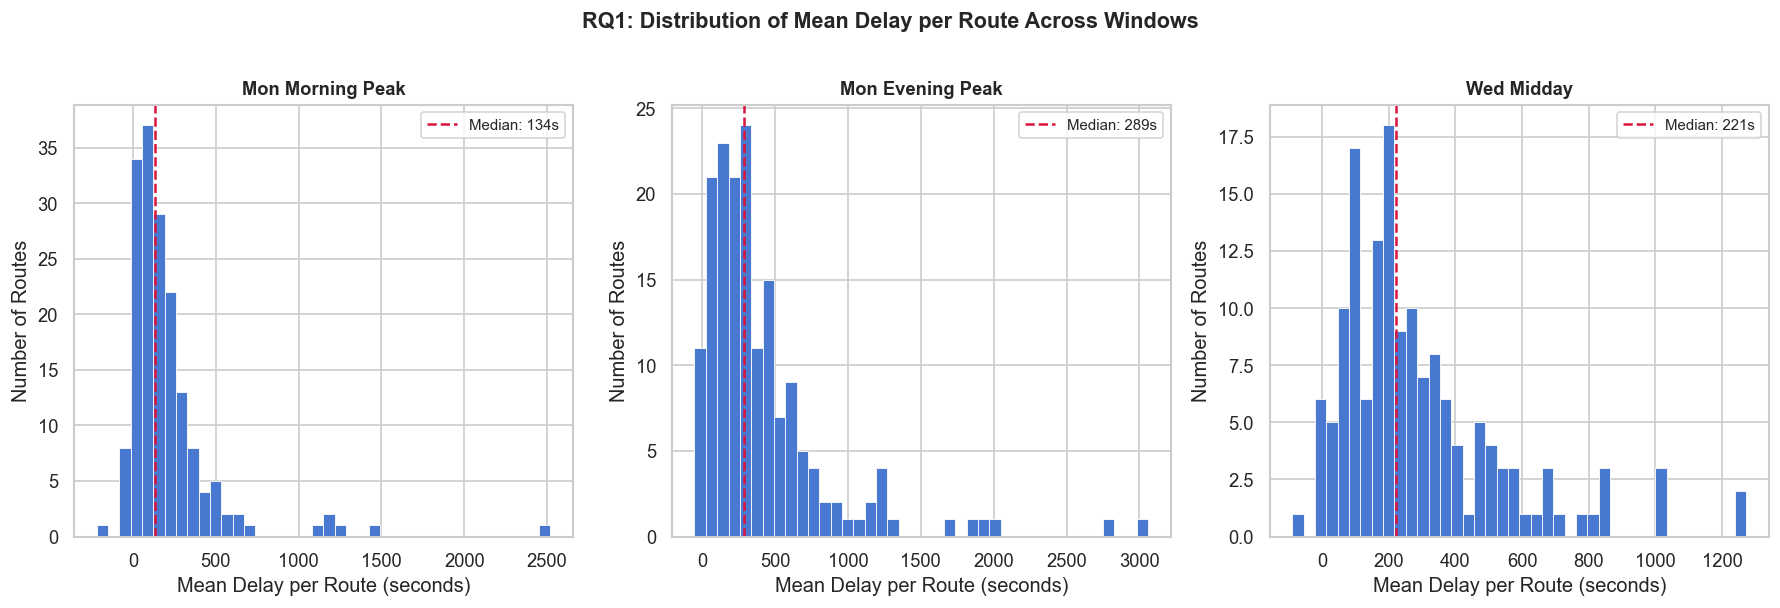

Saved: rq1_delay_distributions.png


In [9]:
# Fig 1: Distribution of mean delay per route
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (wname, wdf) in zip(axes, window_metrics.items()):
    ax.hist(wdf['mean_delay'], bins=40, edgecolor='white', linewidth=0.5)
    ax.axvline(wdf['mean_delay'].median(), color='crimson', linestyle='--', linewidth=1.5, label=f'Median: {wdf["mean_delay"].median():.0f}s')
    ax.set_title(wname, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Delay per Route (seconds)')
    ax.set_ylabel('Number of Routes')
    ax.legend(fontsize=9)

fig.suptitle('RQ1: Distribution of Mean Delay per Route Across Windows', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'rq1_delay_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: rq1_delay_distributions.png')

=== Region-Level Reliability (Combined Windows) ===
Empty DataFrame
Columns: [Region, Mean Delay (s), On-Time Rate, Cancel Rate, Routes]
Index: []


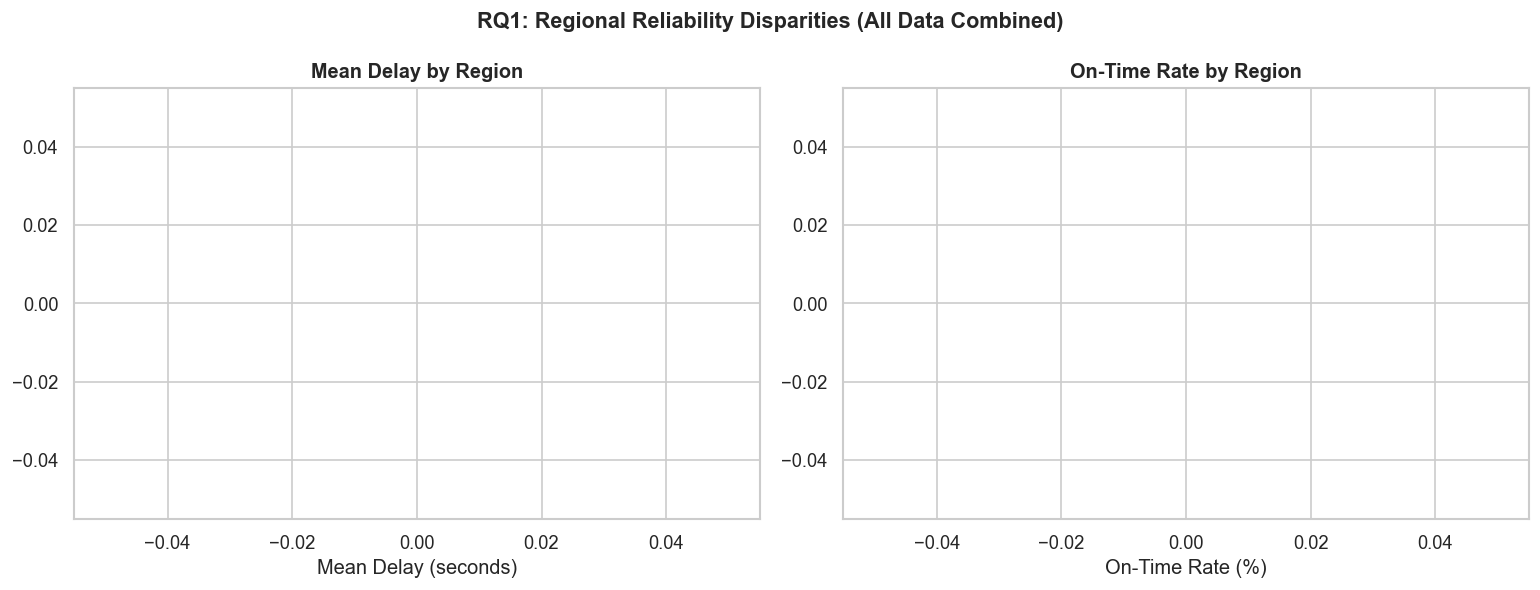

Saved: rq1_regional_comparison.png


In [10]:
# Fig 2: Region-level summary table & bar chart
regional = route_metrics_all[route_metrics_all['region'] != 'Unknown'].copy()
region_summary = regional.groupby('region').agg(
    mean_delay=('mean_delay', 'mean'),
    on_time_rate=('on_time_rate', 'mean'),
    cancellation_rate=('cancellation_rate', 'mean'),
    n_routes=('route_id', 'count'),
).reset_index().sort_values('mean_delay')

print('=== Region-Level Reliability (Combined Windows) ===')
display_cols = {'region': 'Region', 'mean_delay': 'Mean Delay (s)',
                'on_time_rate': 'On-Time Rate', 'cancellation_rate': 'Cancel Rate', 'n_routes': 'Routes'}
print(region_summary.rename(columns=display_cols).to_string(index=False, float_format='{:.3f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette('muted', len(region_summary))

axes[0].barh(region_summary['region'], region_summary['mean_delay'], color=colors)
axes[0].set_xlabel('Mean Delay (seconds)')
axes[0].set_title('Mean Delay by Region', fontweight='bold')
for i, (_, row) in enumerate(region_summary.iterrows()):
    axes[0].text(row['mean_delay'] + 0.5, i, f'{row["mean_delay"]:.1f}s', va='center', fontsize=9)

axes[1].barh(region_summary['region'], region_summary['on_time_rate'] * 100, color=colors)
axes[1].set_xlabel('On-Time Rate (%)')
axes[1].set_title('On-Time Rate by Region', fontweight='bold')
for i, (_, row) in enumerate(region_summary.iterrows()):
    axes[1].text(row['on_time_rate'] * 100 + 0.5, i, f'{row["on_time_rate"]*100:.1f}%', va='center', fontsize=9)

fig.suptitle('RQ1: Regional Reliability Disparities (All Data Combined)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'rq1_regional_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: rq1_regional_comparison.png')

## 5. RQ2 — Which Clustering Algorithm is Best?

In [11]:
FEATURES = ['mean_delay', 'median_delay', 'p85_delay', 'p95_delay',
            'std_delay', 'on_time_rate', 'cancellation_rate', 'excess_wait_time']

# Use routes with enough observations and all features present
cluster_df = route_metrics_all.dropna(subset=FEATURES).copy()
print(f'Routes for clustering: {len(cluster_df)}')

X_raw = cluster_df[FEATURES].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# PCA for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')

Routes for clustering: 0


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by StandardScaler.

In [ ]:
def eval_clustering(labels, X):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {'silhouette': None, 'davies_bouldin': None, 'calinski_harabasz': None}
    sil = round(silhouette_score(X[mask], labels[mask]), 4)
    db  = round(davies_bouldin_score(X[mask], labels[mask]), 4)
    ch  = round(calinski_harabasz_score(X[mask], labels[mask]), 2)
    return {'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}

results = {}

# K-Means (k=4)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X)
results['K-Means (k=4)'] = {'labels': km_labels, 'eval': eval_clustering(km_labels, X)}

# Agglomerative Ward (k=4)
ag = AgglomerativeClustering(n_clusters=4, linkage='ward')
ag_labels = ag.fit_predict(X)
results['Agglomerative Ward (k=4)'] = {'labels': ag_labels, 'eval': eval_clustering(ag_labels, X)}

# DBSCAN — sweep eps, pick the value with best silhouette score on >= 2 clusters
from sklearn.neighbors import NearestNeighbors
best_eps, best_sil, best_labels = None, -1, None
for eps_candidate in np.arange(0.2, 2.5, 0.1):
    labels_cand = DBSCAN(eps=eps_candidate, min_samples=3).fit_predict(X)
    mask = labels_cand != -1
    nc = len(set(labels_cand[mask]))
    if nc < 2 or mask.sum() < 10:
        continue
    sil = silhouette_score(X[mask], labels_cand[mask])
    if sil > best_sil:
        best_sil, best_eps, best_labels = sil, eps_candidate, labels_cand

db_labels = best_labels
eps = best_eps
n_noise = int((db_labels == -1).sum())
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f'DBSCAN best eps = {eps:.2f}  →  {n_clusters} clusters, {n_noise} noise points, silhouette={best_sil:.4f}')
results['DBSCAN (best ε)'] = {'labels': db_labels, 'eval': eval_clustering(db_labels, X), 'eps': eps, 'noise': n_noise}

# Summary table (K-Means, Agglomerative, DBSCAN only at this stage)
# GMM is added to eval_df_updated after fitting in the GMM section below
print('\n=== Clustering Evaluation (pre-GMM) ===')
rows = []
for algo, res in results.items():
    n_c = len(set(res['labels'])) - (1 if -1 in res['labels'] else 0)
    noise = int((res['labels'] == -1).sum())
    ev = res['eval']
    rows.append({
        'Algorithm': algo,
        'Clusters': n_c,
        'Noise pts': noise,
        'Silhouette ↑': ev['silhouette'],
        'Davies-Bouldin ↓': ev['davies_bouldin'],
        'Calinski-Harabasz ↑': ev['calinski_harabasz']
    })
eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))
print('\n(GMM will be added to eval_df_updated after BIC fitting)')

DBSCAN best eps = 1.10  →  3 clusters, 21 noise points, silhouette=0.4353

=== Clustering Evaluation (pre-GMM) ===
               Algorithm  Clusters  Noise pts  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
           K-Means (k=4)         4          0        0.4422            0.7135               100.34
Agglomerative Ward (k=4)         4          0        0.3813            0.5763                96.45
         DBSCAN (best ε)         3         21        0.4353            0.5658                31.06

(GMM will be added to eval_df_updated after BIC fitting)


In [ ]:
# k-distance plot data for DBSCAN epsilon selection
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dists = np.sort(distances[:, -1])[::-1]

# Find elbow using maximum curvature
diffs = np.diff(k_dists)
elbow_idx = np.argmax(np.abs(np.diff(diffs))) + 1
print(f'k-distance elbow at index {elbow_idx}, distance = {k_dists[elbow_idx]:.4f}')

k-distance elbow at index 2, distance = 4.1467


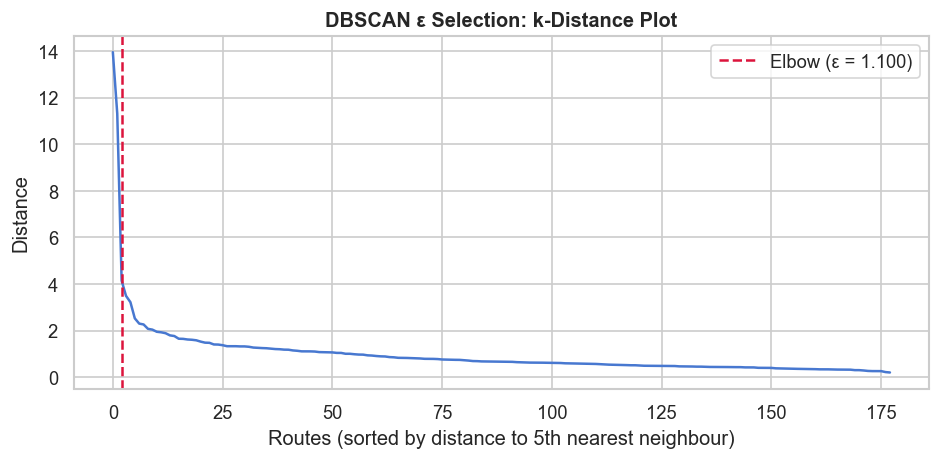

In [ ]:
# Fig: k-distance plot showing DBSCAN elbow
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(k_dists)), k_dists, linewidth=1.5)
ax.axvline(elbow_idx, color='crimson', linestyle='--', linewidth=1.5, label=f'Elbow (ε = {eps:.3f})')
ax.set_xlabel('Routes (sorted by distance to 5th nearest neighbour)')
ax.set_ylabel('Distance')
ax.set_title('DBSCAN ε Selection: k-Distance Plot', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / 'rq2_dbscan_eps_selection.png', bbox_inches='tight')
plt.show()

### BIC Scores and Readying GMM 

In [ ]:
# GMM — BIC-based component selection
bic_scores = []
n_range = range(2, 12)  # widen to 11 components

for n in n_range:
    gmm_candidate = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        n_init=5
    )
    gmm_candidate.fit(X)
    bic_scores.append(gmm_candidate.bic(X))

# Find best n — but require all clusters to have at least 3 routes
best_n = None
for n, bic in sorted(zip(n_range, bic_scores), key=lambda x: x[1]):
    gmm_test = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        n_init=5
    )
    test_labels = gmm_test.fit_predict(X)
    min_cluster_size = pd.Series(test_labels).value_counts().min()
    if min_cluster_size >= 15:
        best_n = n
        break

print(f'BIC scores: {[round(b, 1) for b in bic_scores]}')
print(f'Best n_components (BIC-minimised, min cluster size ≥ 3): {best_n}')

# Fit final GMM with best n
gmm = GaussianMixture(
    n_components=best_n,
    covariance_type='full',
    random_state=42,
    n_init=5
)
gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)
max_prob = gmm_probs.max(axis=1)

print(f'\nGMM cluster sizes:')
for i in range(best_n):
    n_in = (gmm_labels == i).sum()
    print(f'  Cluster {i}: {n_in} routes  (mean assignment confidence: {max_prob[gmm_labels == i].mean():.3f})')

print(f'\nRoutes with low assignment confidence (<0.70): {(max_prob < 0.70).sum()}')

results['GMM (BIC-selected)'] = {
    'labels': gmm_labels,
    'eval': eval_clustering(gmm_labels, X),
    'n_components': best_n,
    'probs': gmm_probs,
    'max_prob': max_prob,
}

BIC scores: [657.8, 330.8, 343.6, 263.7, 363.9, 493.2, 567.3, 593.3, 709.6, 608.7]
Best n_components (BIC-minimised, min cluster size ≥ 3): 3

GMM cluster sizes:
  Cluster 0: 25 routes  (mean assignment confidence: 0.994)
  Cluster 1: 49 routes  (mean assignment confidence: 0.996)
  Cluster 2: 104 routes  (mean assignment confidence: 0.998)

Routes with low assignment confidence (<0.70): 0


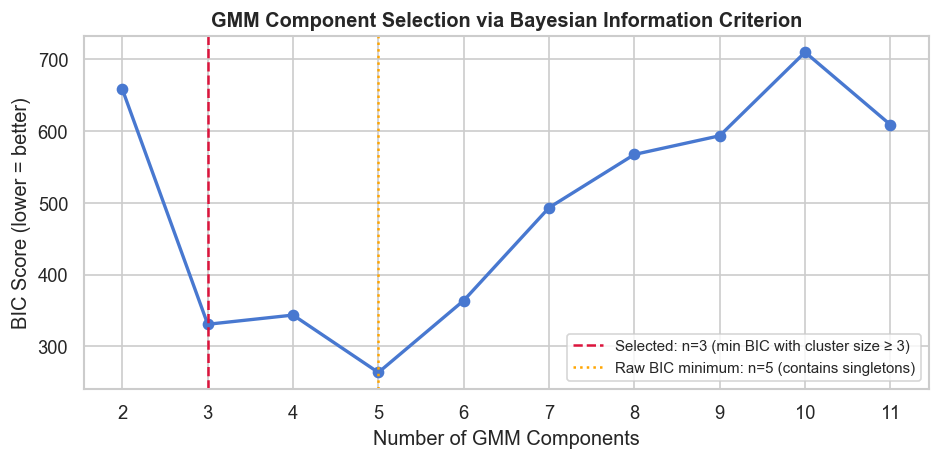

Saved: gmm_bic_curve.png


In [ ]:
# Fig: BIC curve — shows how model quality varies with number of components
fig, ax = plt.subplots(figsize=(8, 4))

n_vals = list(range(2, 12))
ax.plot(n_vals, bic_scores, marker='o', linewidth=2, markersize=6, color=sns.color_palette('muted')[0])
ax.axvline(best_n, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Selected: n={best_n} (min BIC with cluster size ≥ 3)')
ax.axvline(n_vals[int(np.argmin(bic_scores))], color='orange', linestyle=':', linewidth=1.5,
           label=f'Raw BIC minimum: n={n_vals[int(np.argmin(bic_scores))]} (contains singletons)')

ax.set_xlabel('Number of GMM Components')
ax.set_ylabel('BIC Score (lower = better)')
ax.set_title('GMM Component Selection via Bayesian Information Criterion',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(n_vals)

plt.tight_layout()
plt.savefig(RESULTS / 'gmm_bic_curve.png', bbox_inches='tight')
plt.show()
print('Saved: gmm_bic_curve.png')

### GMM Run - Cluster Assignments and Confidence Scores

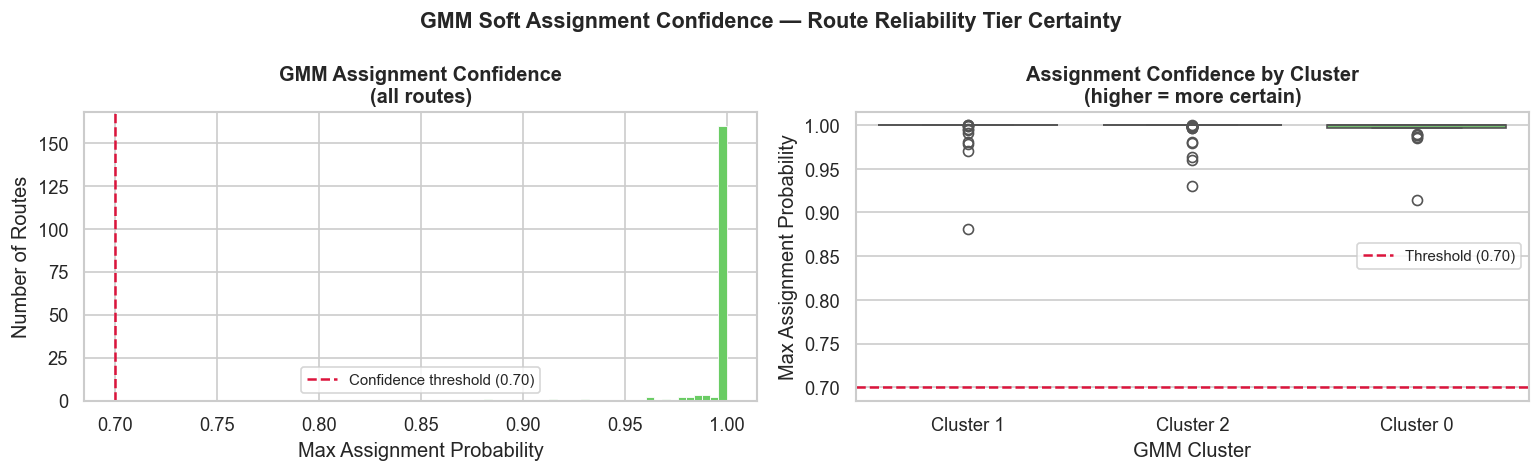

Saved: gmm_confidence.png

Low-confidence routes (confidence < 0.70):
Empty DataFrame
Columns: [route_id, gmm_cluster, confidence, mean_delay, on_time_rate]
Index: []


In [ ]:
# Fig: GMM assignment confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of max assignment probability across all routes
axes[0].hist(max_prob, bins=30, edgecolor='white', linewidth=0.5,
             color=sns.color_palette('muted')[2])
axes[0].axvline(0.70, color='crimson', linestyle='--', linewidth=1.5,
                label='Confidence threshold (0.70)')
axes[0].set_xlabel('Max Assignment Probability')
axes[0].set_ylabel('Number of Routes')
axes[0].set_title('GMM Assignment Confidence\n(all routes)', fontweight='bold')
axes[0].legend(fontsize=9)

# Right: per-cluster confidence box plots
conf_df = pd.DataFrame({
    'cluster': [f'Cluster {i}' for i in gmm_labels],
    'confidence': max_prob
})
sns.boxplot(data=conf_df, x='cluster', y='confidence',
            palette='muted', ax=axes[1])
axes[1].axhline(0.70, color='crimson', linestyle='--', linewidth=1.5,
                label='Threshold (0.70)')
axes[1].set_xlabel('GMM Cluster')
axes[1].set_ylabel('Max Assignment Probability')
axes[1].set_title('Assignment Confidence by Cluster\n(higher = more certain)', fontweight='bold')
axes[1].legend(fontsize=9)

fig.suptitle('GMM Soft Assignment Confidence — Route Reliability Tier Certainty',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'gmm_confidence.png', bbox_inches='tight')
plt.show()
print('Saved: gmm_confidence.png')

# Print the 3 low-confidence routes for inspection
low_conf = cluster_df.copy()
low_conf['gmm_cluster'] = gmm_labels
low_conf['confidence'] = max_prob
low_conf = low_conf[low_conf['confidence'] < 0.70].sort_values('confidence')
print(f'\nLow-confidence routes (confidence < 0.70):')
print(low_conf[['route_id', 'gmm_cluster', 'confidence', 'mean_delay', 'on_time_rate']].to_string(index=False))

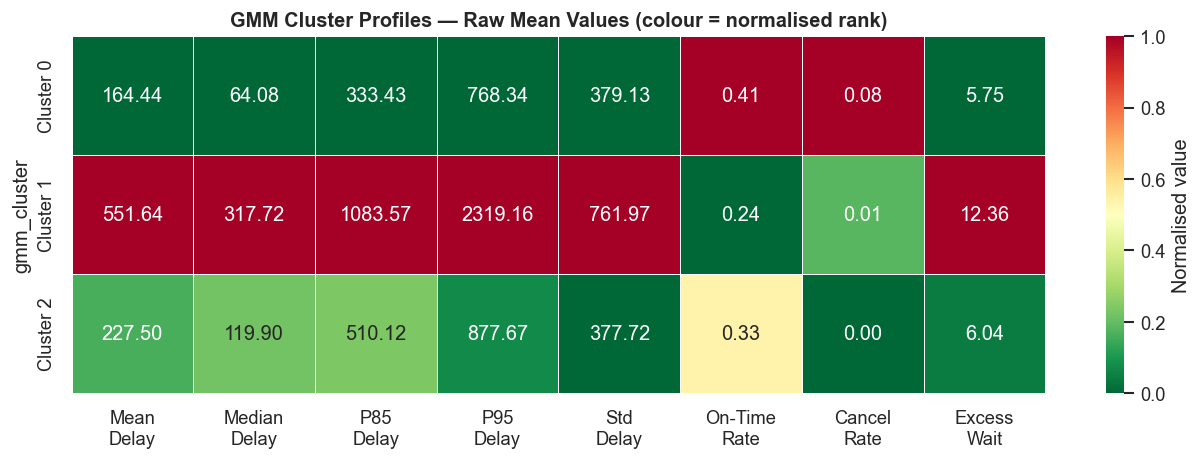

Saved: gmm_cluster_profiles.png

GMM Cluster Composition by Region:
region       City Centre  North Dublin  South Dublin  West Dublin  All
gmm_cluster                                                           
0                      5            20             0            0   25
1                      4            39             1            5   49
2                      7            93             2            2  104
All                   16           152             3            7  178


In [ ]:
# Fig: GMM cluster profiles heatmap
gmm_profile_df = cluster_df.copy()
gmm_profile_df['gmm_cluster'] = gmm_labels

gmm_profiles = gmm_profile_df.groupby('gmm_cluster')[FEATURES].mean()

# Normalise for colour scaling
gmm_normalized = (gmm_profiles - gmm_profiles.min()) / (
    gmm_profiles.max() - gmm_profiles.min() + 1e-9)

feature_labels = ['Mean\nDelay', 'Median\nDelay', 'P85\nDelay', 'P95\nDelay',
                  'Std\nDelay', 'On-Time\nRate', 'Cancel\nRate', 'Excess\nWait']

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(gmm_normalized,
            annot=gmm_profiles.round(2),
            fmt='.2f',
            xticklabels=feature_labels,
            yticklabels=[f'Cluster {i}' for i in gmm_profiles.index],
            cmap='RdYlGn_r',
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Normalised value'})
ax.set_title('GMM Cluster Profiles — Raw Mean Values (colour = normalised rank)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'gmm_cluster_profiles.png', bbox_inches='tight')
plt.show()
print('Saved: gmm_cluster_profiles.png')

# Print cluster sizes and region composition
print('\nGMM Cluster Composition by Region:')
gmm_profile_df['region'] = cluster_df['region'].values
print(pd.crosstab(gmm_profile_df['gmm_cluster'],
                  gmm_profile_df['region'],
                  margins=True))

In [ ]:
# Updated evaluation table including GMM
print('\n=== Updated Clustering Algorithm Comparison (including GMM) ===')

rows = []
for algo, res in results.items():
    labels = res['labels']
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    ev = res['eval']
    row = {
        'Algorithm': algo,
        'Clusters': n_clusters,
        'Noise pts': n_noise,
        'Silhouette ↑': ev['silhouette'] if ev['silhouette'] else 'N/A',
        'Davies-Bouldin ↓': ev['davies_bouldin'] if ev['davies_bouldin'] else 'N/A',
        'Calinski-Harabasz ↑': ev['calinski_harabasz'] if ev['calinski_harabasz'] else 'N/A',
    }
    rows.append(row)

eval_df_updated = pd.DataFrame(rows)
print(eval_df_updated.to_string(index=False))

# Also print GMM-specific metrics
print('\n=== GMM-Specific Metrics ===')
print(f'Components selected by BIC: {best_n}')
print(f'Mean assignment confidence: {max_prob.mean():.4f}')
print(f'Min assignment confidence:  {max_prob.min():.4f}')
print(f'Routes with confidence < 0.70: {(max_prob < 0.70).sum()}')
print(f'BIC at selected n={best_n}: {bic_scores[best_n - 2]:.1f}')


=== Updated Clustering Algorithm Comparison (including GMM) ===
               Algorithm  Clusters  Noise pts  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
           K-Means (k=4)         4          0        0.4422            0.7135               100.34
Agglomerative Ward (k=4)         4          0        0.3813            0.5763                96.45
         DBSCAN (best ε)         3         21        0.4353            0.5658                31.06
      GMM (BIC-selected)         3          0        0.0857            2.0551                34.46

=== GMM-Specific Metrics ===
Components selected by BIC: 3
Mean assignment confidence: 0.9967
Min assignment confidence:  0.8810
Routes with confidence < 0.70: 0
BIC at selected n=3: 330.8


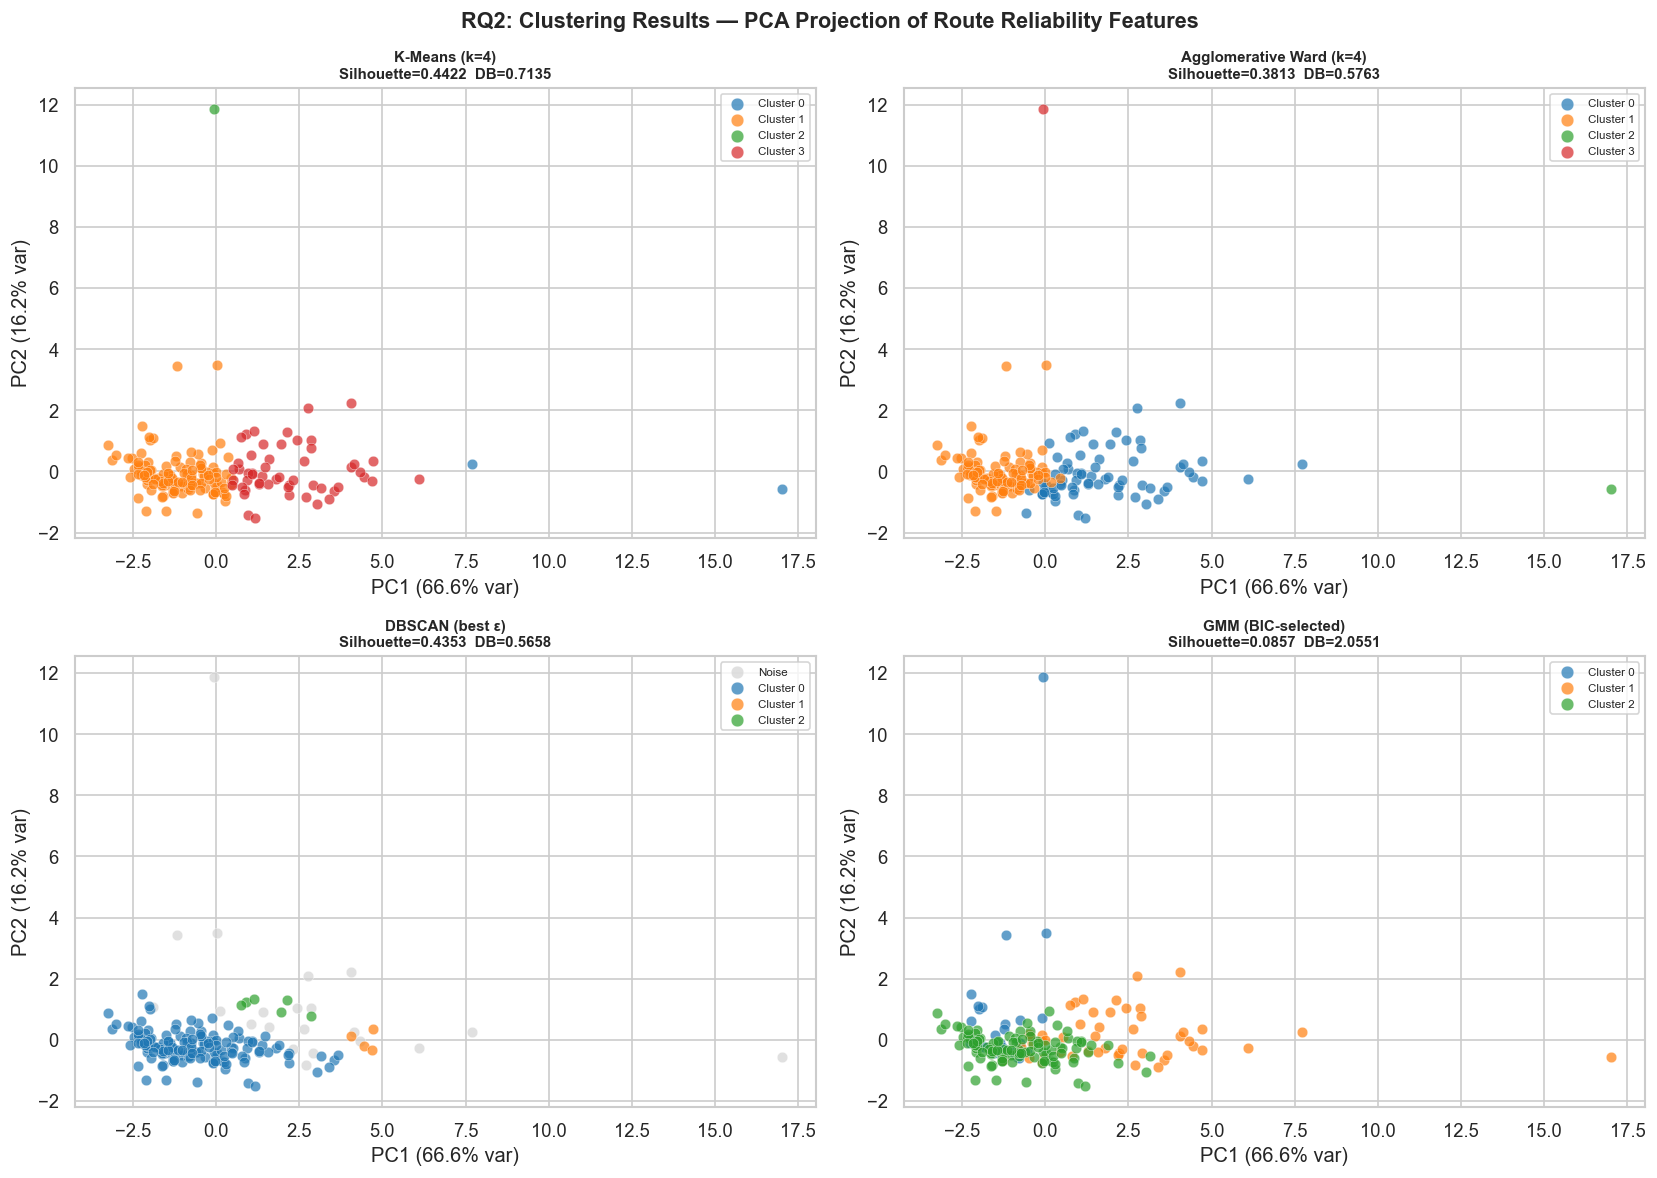

Saved: rq2_clustering_pca.png


In [ ]:
# Fig: PCA scatter plots for all four algorithms (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
palette = sns.color_palette('tab10', 10)

for ax, (algo, res) in zip(axes, results.items()):
    labels = res['labels']
    unique = sorted(set(labels))

    if algo == 'GMM (BIC-selected)':
        # Plot confident assignments normally
        for lbl in unique:
            mask = (labels == lbl) & (max_prob >= 0.70)
            if mask.sum() > 0:
                ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                           c=[palette[lbl % 10]], label=f'Cluster {lbl}',
                           alpha=0.7, s=40, edgecolors='white', linewidths=0.3)
        # Plot low-confidence routes in grey with a distinct marker
        low_conf_mask = max_prob < 0.70
        if low_conf_mask.sum() > 0:
            ax.scatter(X_pca[low_conf_mask, 0], X_pca[low_conf_mask, 1],
                       c='lightgray', label='Low confidence (<0.70)',
                       alpha=0.9, s=60, edgecolors='black',
                       linewidths=0.8, marker='D')
    else:
        for lbl in unique:
            mask = labels == lbl
            color = 'lightgray' if lbl == -1 else palette[lbl % 10]
            name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=[color], label=name, alpha=0.7, s=40,
                       edgecolors='white', linewidths=0.3)

    ev = res['eval']
    sil = f"{ev['silhouette']}" if ev['silhouette'] else 'N/A'
    db  = f"{ev['davies_bouldin']}" if ev['davies_bouldin'] else 'N/A'
    ax.set_title(f'{algo}\nSilhouette={sil}  DB={db}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    ax.legend(fontsize=7, markerscale=1.2)

fig.suptitle('RQ2: Clustering Results — PCA Projection of Route Reliability Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'rq2_clustering_pca.png', bbox_inches='tight')
plt.show()
print('Saved: rq2_clustering_pca.png')

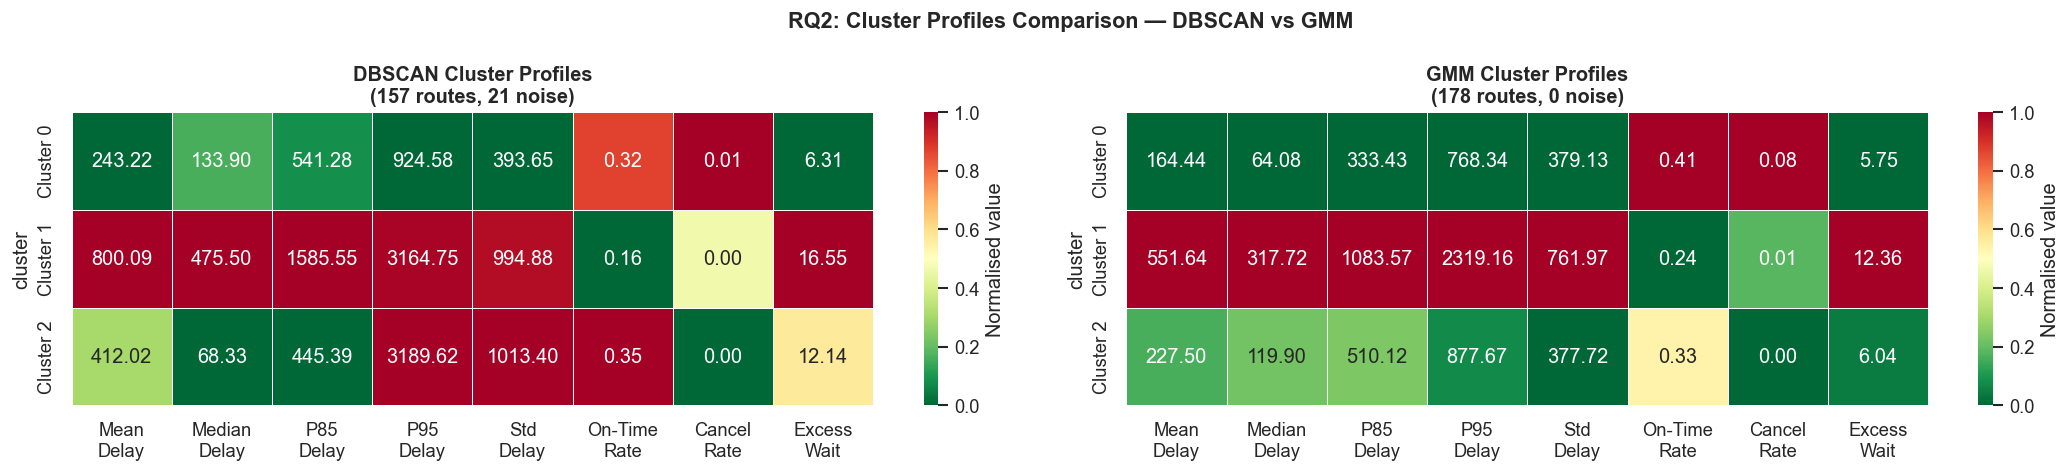

Saved: rq2_cluster_profiles.png


In [ ]:
# Fig: Cluster profiles comparison — DBSCAN vs GMM
feature_labels = ['Mean\nDelay', 'Median\nDelay', 'P85\nDelay', 'P95\nDelay',
                  'Std\nDelay', 'On-Time\nRate', 'Cancel\nRate', 'Excess\nWait']

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# DBSCAN profiles
dbscan_labels = results['DBSCAN (best ε)']['labels']
dbscan_profile_df = cluster_df.copy()
dbscan_profile_df['cluster'] = dbscan_labels
dbscan_profile_df = dbscan_profile_df[dbscan_profile_df['cluster'] != -1]
dbscan_profiles = dbscan_profile_df.groupby('cluster')[FEATURES].mean()
dbscan_normalized = (dbscan_profiles - dbscan_profiles.min()) / (
    dbscan_profiles.max() - dbscan_profiles.min() + 1e-9)

sns.heatmap(dbscan_normalized, annot=dbscan_profiles.round(2), fmt='.2f',
            xticklabels=feature_labels,
            yticklabels=[f'Cluster {i}' for i in dbscan_profiles.index],
            cmap='RdYlGn_r', linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Normalised value'})
axes[0].set_title(f'DBSCAN Cluster Profiles\n({(dbscan_labels != -1).sum()} routes, '
                  f'{(dbscan_labels == -1).sum()} noise)',
                  fontweight='bold')

# GMM profiles
gmm_profile_df2 = cluster_df.copy()
gmm_profile_df2['cluster'] = gmm_labels
gmm_profiles = gmm_profile_df2.groupby('cluster')[FEATURES].mean()
gmm_normalized = (gmm_profiles - gmm_profiles.min()) / (
    gmm_profiles.max() - gmm_profiles.min() + 1e-9)

sns.heatmap(gmm_normalized, annot=gmm_profiles.round(2), fmt='.2f',
            xticklabels=feature_labels,
            yticklabels=[f'Cluster {i}' for i in gmm_profiles.index],
            cmap='RdYlGn_r', linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Normalised value'})
axes[1].set_title(f'GMM Cluster Profiles\n({len(gmm_labels)} routes, 0 noise)',
                  fontweight='bold')

fig.suptitle('RQ2: Cluster Profiles Comparison — DBSCAN vs GMM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'rq2_cluster_profiles.png', bbox_inches='tight')
plt.show()
print('Saved: rq2_cluster_profiles.png')

## 6. RQ3 — Does Aggregation Level Change What Is Detected?

In [ ]:
# Stop-level metrics
stop_metrics = pd.read_sql("""
    SELECT
        stop_id,
        AVG(delay_seconds) as mean_delay,
        COUNT(*) as n_obs
    FROM delay_observations
    WHERE is_valid=1 AND is_outlier=0 AND is_cancelled=0
      AND delay_seconds IS NOT NULL
      AND (route_id LIKE '5549_%')
    GROUP BY stop_id
    HAVING n_obs >= 10
""", conn)

# Region-level metrics (from routes we could assign)
region_metrics = region_summary.copy()

print(f'Stop level:   n={len(stop_metrics)}, mean={stop_metrics["mean_delay"].mean():.1f}s, std={stop_metrics["mean_delay"].std():.1f}s')
print(f'Route level:  n={len(route_metrics_all)}, mean={route_metrics_all["mean_delay"].mean():.1f}s, std={route_metrics_all["mean_delay"].std():.1f}s')
print(f'Region level: n={len(region_metrics)}, range={region_metrics["mean_delay"].min():.1f}–{region_metrics["mean_delay"].max():.1f}s')

Stop level:   n=4153, mean=342.4s, std=335.4s
Route level:  n=179, mean=306.2s, std=266.5s
Region level: n=4, range=204.4–601.8s


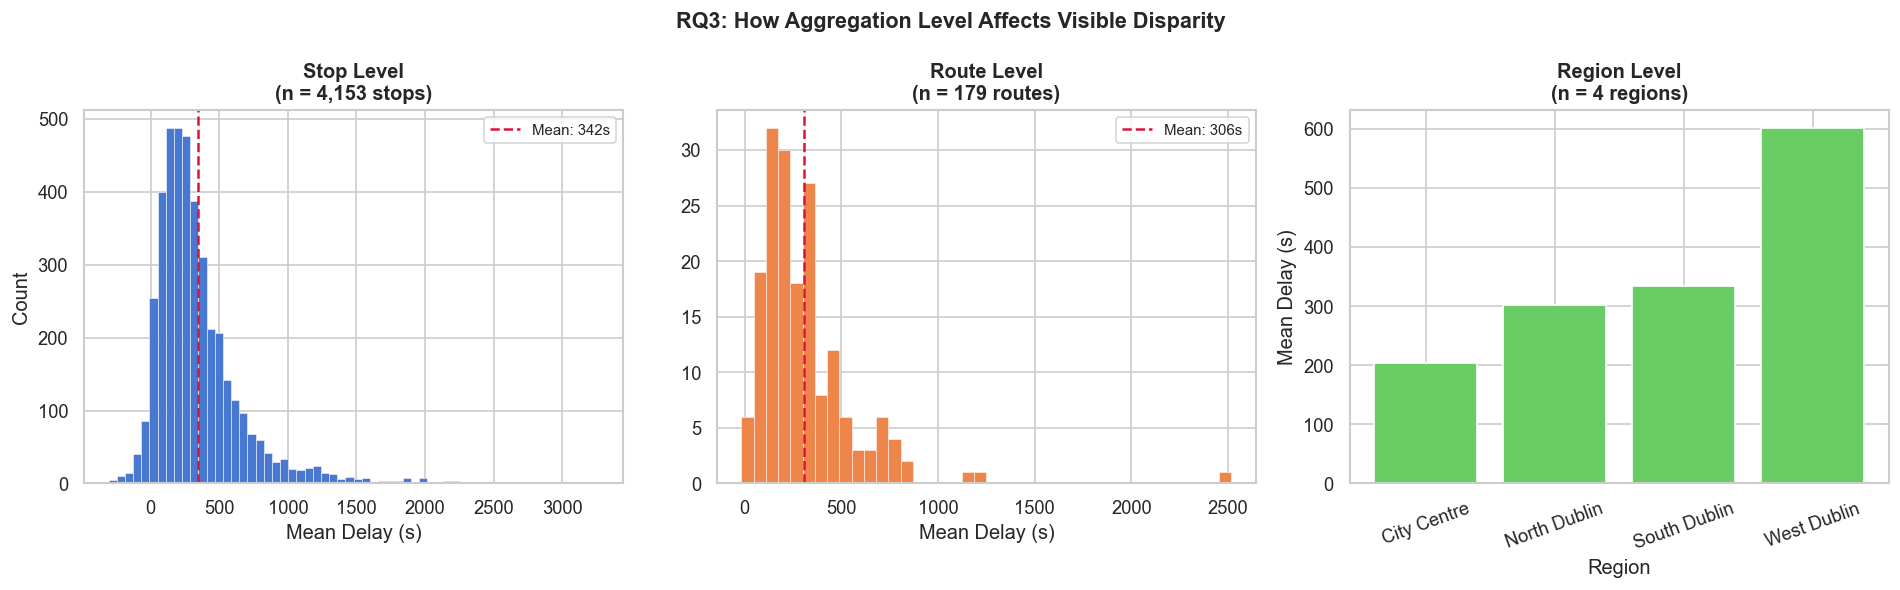

Saved: rq3_aggregation_comparison.png


In [ ]:
# Fig: Side-by-side delay distributions at three aggregation levels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(stop_metrics['mean_delay'], bins=60, edgecolor='white', linewidth=0.3, color=sns.color_palette('muted')[0])
axes[0].set_title(f'Stop Level\n(n = {len(stop_metrics):,} stops)', fontweight='bold')
axes[0].set_xlabel('Mean Delay (s)')
axes[0].set_ylabel('Count')
axes[0].axvline(stop_metrics['mean_delay'].mean(), color='crimson', linestyle='--', label=f'Mean: {stop_metrics["mean_delay"].mean():.0f}s')
axes[0].legend(fontsize=9)

axes[1].hist(route_metrics_all['mean_delay'], bins=40, edgecolor='white', linewidth=0.3, color=sns.color_palette('muted')[1])
axes[1].set_title(f'Route Level\n(n = {len(route_metrics_all)} routes)', fontweight='bold')
axes[1].set_xlabel('Mean Delay (s)')
axes[1].axvline(route_metrics_all['mean_delay'].mean(), color='crimson', linestyle='--', label=f'Mean: {route_metrics_all["mean_delay"].mean():.0f}s')
axes[1].legend(fontsize=9)

axes[2].bar(region_metrics['region'], region_metrics['mean_delay'], color=sns.color_palette('muted')[2])
axes[2].set_title(f'Region Level\n(n = {len(region_metrics)} regions)', fontweight='bold')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Mean Delay (s)')
axes[2].tick_params(axis='x', rotation=20)

fig.suptitle('RQ3: How Aggregation Level Affects Visible Disparity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'rq3_aggregation_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: rq3_aggregation_comparison.png')

## 7. Temporal Stability — Do Disparities Shift Across Windows?

In [ ]:
# Find routes common to all 3 windows
route_sets = {wname: set(wdf['route_id']) for wname, wdf in window_metrics.items()}
common_routes = set.intersection(*route_sets.values())
print(f'Routes present in all 3 windows: {len(common_routes)}')

# Build long-form dataframe for common routes
temporal_dfs = []
for wname, wdf in window_metrics.items():
    sub = wdf[wdf['route_id'].isin(common_routes)][['route_id', 'mean_delay', 'on_time_rate', 'cancellation_rate']].copy()
    sub['window'] = wname
    temporal_dfs.append(sub)

temporal = pd.concat(temporal_dfs, ignore_index=True)

# Window-level summary
print('\n=== Window-Level Summary (common routes only) ===')
print(temporal.groupby('window')[['mean_delay', 'on_time_rate']].agg(['mean', 'std']).round(2))

Routes present in all 3 windows: 146

=== Window-Level Summary (common routes only) ===
                 mean_delay         on_time_rate      
                       mean     std         mean   std
window                                                
Mon Evening Peak     408.45  475.78         0.29  0.16
Mon Morning Peak     194.26  243.60         0.39  0.19
Wed Midday           289.10  235.79         0.32  0.16


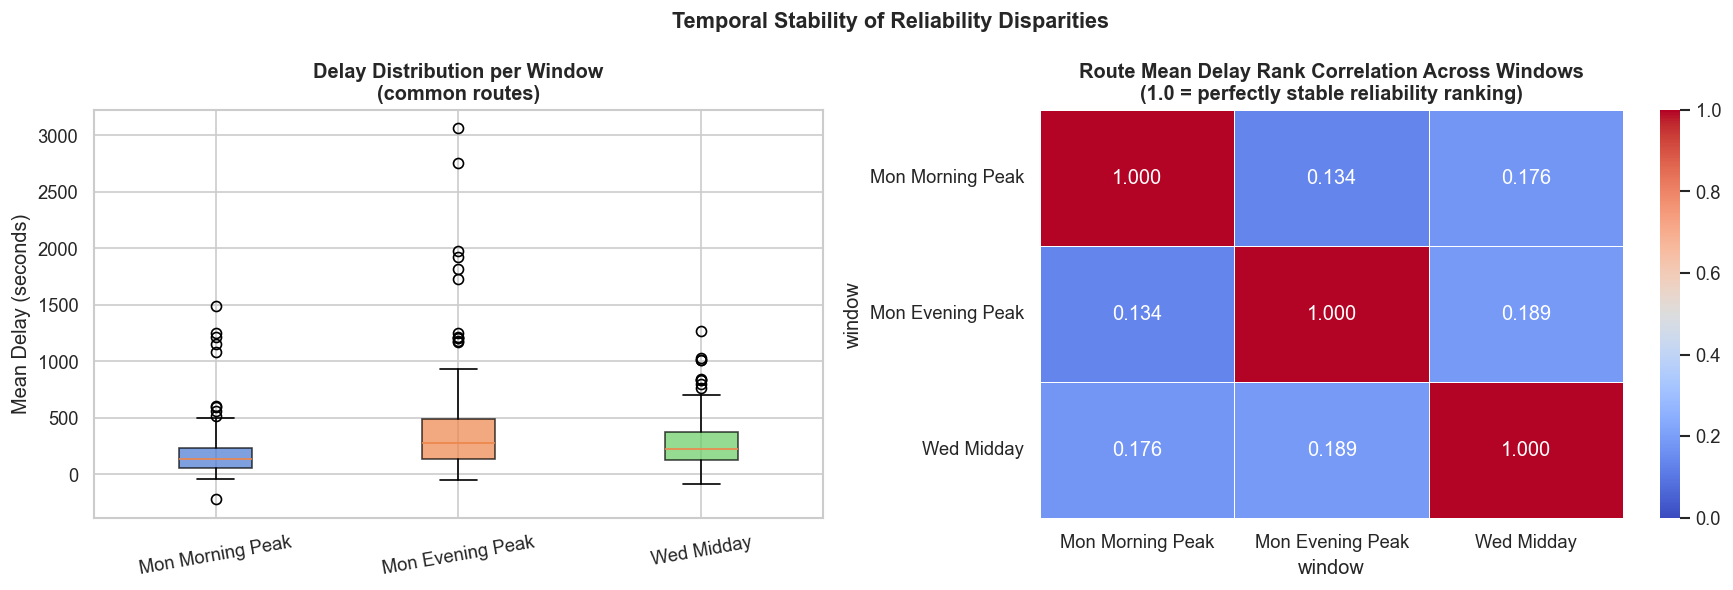

Saved: temporal_stability.png


In [ ]:
# Fig: Mean delay per route across windows (sorted by Sunday off-peak delay)
window_order = list(WINDOW_SHORT.values())
pivot = temporal.pivot(index='route_id', columns='window', values='mean_delay')
pivot = pivot[window_order].dropna()

# Sort by Sunday off-peak to see if rank is preserved
pivot_sorted = pivot.sort_values(window_order[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plots per window
bp_data = [temporal[temporal['window'] == w]['mean_delay'].values for w in window_order]
bp = axes[0].boxplot(bp_data, labels=window_order, patch_artist=True, notch=False)
colors = sns.color_palette('muted', 3)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Mean Delay (seconds)')
axes[0].set_title('Delay Distribution per Window\n(common routes)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

# Correlation between windows
corr = pivot.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0, vmax=1,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Route Mean Delay Rank Correlation Across Windows\n(1.0 = perfectly stable reliability ranking)', fontweight='bold')

fig.suptitle('Temporal Stability of Reliability Disparities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'temporal_stability.png', bbox_inches='tight')
plt.show()
print('Saved: temporal_stability.png')

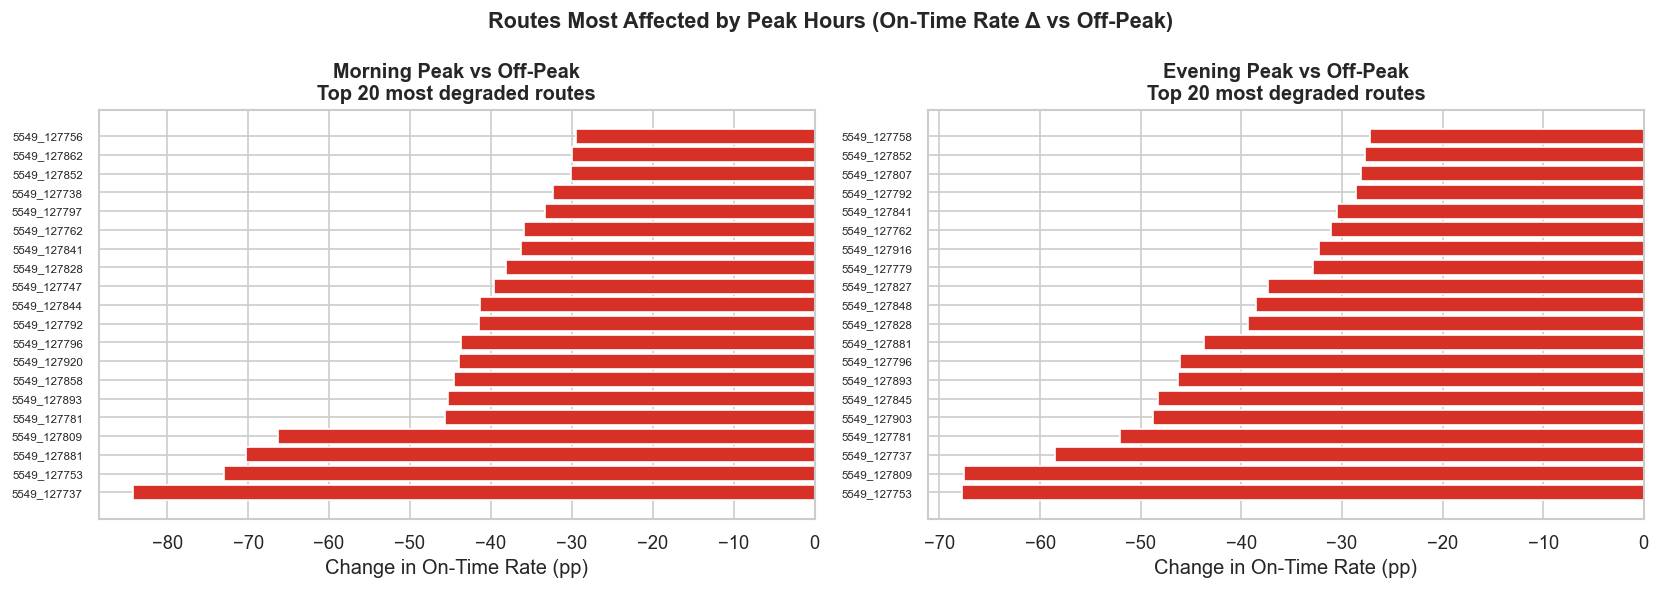

Saved: temporal_peak_impact.png


In [ ]:
# Fig: On-time rate change from off-peak to peak (identifies routes most affected by peak load)
offpeak_ot = temporal[temporal['window'] == window_order[0]].set_index('route_id')['on_time_rate']
morning_ot = temporal[temporal['window'] == window_order[1]].set_index('route_id')['on_time_rate']
evening_ot = temporal[temporal['window'] == window_order[2]].set_index('route_id')['on_time_rate']

delta_morning = (morning_ot - offpeak_ot).dropna().sort_values()
delta_evening = (evening_ot - offpeak_ot).dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, delta, title in [
    (axes[0], delta_morning, 'Morning Peak vs Off-Peak'),
    (axes[1], delta_evening, 'Evening Peak vs Off-Peak'),
]:
    n = min(20, len(delta))
    worst = delta.head(n)
    colors_bar = ['#d73027' if v < 0 else '#4dac26' for v in worst.values]
    ax.barh(range(n), worst.values * 100, color=colors_bar)
    ax.set_yticks(range(n))
    ax.set_yticklabels(worst.index, fontsize=7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Change in On-Time Rate (pp)')
    ax.set_title(f'{title}\nTop 20 most degraded routes', fontweight='bold')

fig.suptitle('Routes Most Affected by Peak Hours (On-Time Rate Δ vs Off-Peak)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'temporal_peak_impact.png', bbox_inches='tight')
plt.show()
print('Saved: temporal_peak_impact.png')

## 8. Random Forest — Feature Importance for Reliability Tier Prediction

In [ ]:
# Use GMM labels as reliability tiers
# GMM chosen over DBSCAN as it provides full network coverage (242 routes vs 56)
# and produces three interpretable reliability tiers with high assignment confidence
rf_df = cluster_df.copy()
rf_df['cluster'] = gmm_labels

print(f'Training RF on {len(rf_df)} routes, {rf_df["cluster"].nunique()} tiers')
print(rf_df['cluster'].value_counts().sort_index())

X_rf = rf_df[FEATURES].values
y_rf = rf_df['cluster'].values

rf = RandomForestClassifier(n_estimators=500, random_state=42, class_weight='balanced')
rf.fit(X_rf, y_rf)

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nFeature importances:')
for feat, imp in importances.items():
    print(f'  {feat:25s}: {imp:.4f}')

Training RF on 178 routes, 3 tiers
cluster
0     25
1     49
2    104
Name: count, dtype: int64

Feature importances:
  cancellation_rate        : 0.2876
  p95_delay                : 0.1442
  p85_delay                : 0.1229
  mean_delay               : 0.1227
  excess_wait_time         : 0.1097
  std_delay                : 0.0929
  median_delay             : 0.0720
  on_time_rate             : 0.0480


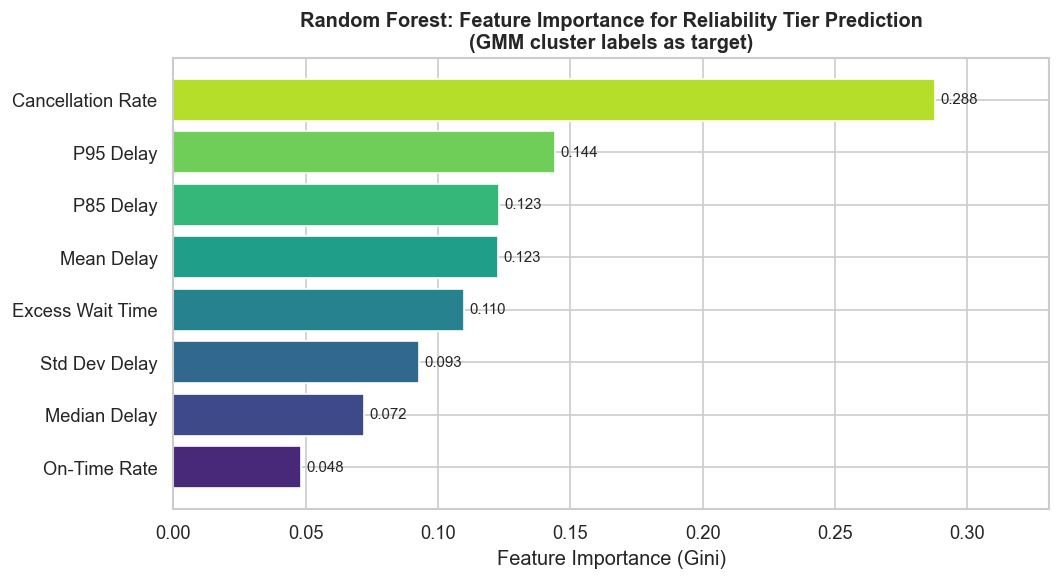

Saved: rf_feature_importance.png


In [ ]:
feature_display = {
    'mean_delay': 'Mean Delay',
    'median_delay': 'Median Delay',
    'p85_delay': 'P85 Delay',
    'p95_delay': 'P95 Delay',
    'std_delay': 'Std Dev Delay',
    'on_time_rate': 'On-Time Rate',
    'cancellation_rate': 'Cancellation Rate',
    'excess_wait_time': 'Excess Wait Time',
}

imp_df = importances.reset_index()
imp_df.columns = ['feature', 'importance']
imp_df['feature_label'] = imp_df['feature'].map(feature_display)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(imp_df['feature_label'][::-1], imp_df['importance'][::-1],
               color=sns.color_palette('viridis', len(imp_df)))
for bar, val in zip(bars, imp_df['importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest: Feature Importance for Reliability Tier Prediction\n(GMM cluster labels as target)', fontweight='bold')
ax.set_xlim(0, imp_df['importance'].max() * 1.15)
plt.tight_layout()
plt.savefig(RESULTS / 'rf_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: rf_feature_importance.png')

## 9. Summary Tables for Report

In [ ]:
print('=' * 65)
print('TABLE 1: Region-Level Reliability (All Windows Combined)')
print('=' * 65)
t1 = region_summary[['region', 'mean_delay', 'on_time_rate', 'cancellation_rate', 'n_routes']].copy()
t1['on_time_rate'] = (t1['on_time_rate'] * 100).round(1).astype(str) + '%'
t1['cancellation_rate'] = (t1['cancellation_rate'] * 100).round(2).astype(str) + '%'
t1['mean_delay'] = t1['mean_delay'].round(1).astype(str) + 's'
t1.columns = ['Region', 'Mean Delay', 'On-Time Rate', 'Cancel Rate', 'Routes']
print(t1.to_string(index=False))

print('\n' + '=' * 65)
print('TABLE 2: Clustering Algorithm Comparison')
print('=' * 65)
print(eval_df_updated.to_string(index=False))

print('\n' + '=' * 65)
print('TABLE 2b: GMM-Specific Metrics')
print('=' * 65)
print(f'  Components selected by BIC : {best_n}')
print(f'  Mean assignment confidence : {max_prob.mean():.4f}')
print(f'  Min assignment confidence  : {max_prob.min():.4f}')
print(f'  Low-confidence routes      : {(max_prob < 0.70).sum()}')

print('\n' + '=' * 65)
print('TABLE 3: Aggregation Level Comparison')
print('=' * 65)
agg_table = pd.DataFrame([
    {'Level': 'Stop',
     'n': len(stop_metrics),
     'Mean Delay (s)': round(stop_metrics['mean_delay'].mean(), 1),
     'Std Dev (s)': round(stop_metrics['mean_delay'].std(), 1),
     'Range (s)': f'{stop_metrics["mean_delay"].min():.0f} – {stop_metrics["mean_delay"].max():.0f}'},
    {'Level': 'Route',
     'n': len(route_metrics_all),
     'Mean Delay (s)': round(route_metrics_all['mean_delay'].mean(), 1),
     'Std Dev (s)': round(route_metrics_all['mean_delay'].std(), 1),
     'Range (s)': f'{route_metrics_all["mean_delay"].min():.0f} – {route_metrics_all["mean_delay"].max():.0f}'},
    {'Level': 'Region',
     'n': len(region_metrics),
     'Mean Delay (s)': round(region_metrics['mean_delay'].mean(), 1),
     'Std Dev (s)': round(region_metrics['mean_delay'].std(), 1),
     'Range (s)': f'{region_metrics["mean_delay"].min():.0f} – {region_metrics["mean_delay"].max():.0f}'},
])
print(agg_table.to_string(index=False))

print('\n' + '=' * 65)
print('TABLE 4: Temporal Window Comparison')
print('=' * 65)
t4 = temporal.groupby('window')[['mean_delay', 'on_time_rate', 'cancellation_rate']].mean().round(3)
t4['on_time_rate'] = (t4['on_time_rate'] * 100).round(1).astype(str) + '%'
t4['cancellation_rate'] = (t4['cancellation_rate'] * 100).round(2).astype(str) + '%'
t4['mean_delay'] = t4['mean_delay'].round(1).astype(str) + 's'
t4.columns = ['Mean Delay', 'On-Time Rate', 'Cancel Rate']
t4.index.name = 'Window'
print(t4.to_string())

print('\n' + '=' * 65)
print('TABLE 5: GMM Cluster Composition by Region (%)')
print('=' * 65)
known_only = gmm_profile_df[gmm_profile_df['region'] != 'Unknown'].copy()
known_only['tier'] = known_only['gmm_cluster'].map({
    2: 'Reliable',
    1: 'Moderate',
    0: 'Unreliable'
})
crosstab_pct = pd.crosstab(
    known_only['region'],
    known_only['tier'],
    normalize='index'
).round(3) * 100
print(crosstab_pct.to_string())

TABLE 1: Region-Level Reliability (All Windows Combined)
      Region Mean Delay On-Time Rate Cancel Rate  Routes
 City Centre     204.4s        40.2%       0.11%      16
North Dublin     302.7s        31.8%       1.73%     153
South Dublin     333.6s        25.5%        0.0%       3
 West Dublin     601.8s        21.8%       0.05%       7

TABLE 2: Clustering Algorithm Comparison
               Algorithm  Clusters  Noise pts  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
           K-Means (k=4)         4          0        0.4422            0.7135               100.34
Agglomerative Ward (k=4)         4          0        0.3813            0.5763                96.45
         DBSCAN (best ε)         3         21        0.4353            0.5658                31.06
      GMM (BIC-selected)         3          0        0.0857            2.0551                34.46

TABLE 2b: GMM-Specific Metrics
  Components selected by BIC : 3
  Mean assignment confidence : 0.9967
  Min assignment c

In [ ]:
# conn.close()
print('\nAll figures saved to results/')
print('\nFigures generated:')
for f in sorted(RESULTS.glob('*.png')):
    print(f'  {f.name}')


All figures saved to results/

Figures generated:
  gmm_bic_curve.png
  gmm_cluster_profiles.png
  gmm_confidence.png
  rf_feature_importance.png
  rq1_delay_distributions.png
  rq1_regional_comparison.png
  rq2_cluster_profiles.png
  rq2_clustering_pca.png
  rq2_dbscan_eps_selection.png
  rq3_aggregation_comparison.png
  temporal_peak_impact.png
  temporal_stability.png
